# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`datasets/instacart_orders.csv`, `datasets/products.csv`, `datasets/aisles.csv`, `datasets/departments.csv` y `datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

Primero, leeré los cinco archivos CSV con pd.read_csv(), utilizando el separador adecuado después de revisar el formato de los archivos. Guardaré cada tabla en un DataFrame diferente. Después, utilizaré head() para observar las primeras filas e identificar la estructura y el contenido general de cada tabla. También utilizaré info() para revisar el número de filas y columnas, los tipos de datos y la presencia de valores ausentes. Para order_products, utilizaré info(show_counts=True) debido a su gran cantidad de filas. Finalmente, registraré las observaciones iniciales sobre cada DataFrame antes de comenzar la limpieza de los datos.


In [66]:
# importar librerías
import pandas as pd

In [67]:
# leer conjuntos de datos en los DataFrames
orders = pd.read_csv(
    'datasets/instacart_orders.csv',
    sep=';'
)

products = pd.read_csv(
    'datasets/products.csv',
    sep=';'
)

aisles = pd.read_csv(
    'datasets/aisles.csv',
    sep=';'
)

departments = pd.read_csv(
    'datasets/departments.csv',
    sep=';'
)

order_products = pd.read_csv(
    'datasets/order_products.csv',
    sep=';'
)

In [68]:
# mostrar información del DataFrame
print(orders.head())
orders.info()

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12   

   days_since_prior_order  
0                    30.0  
1                     9.0  
2                     2.0  
3                    10.0  
4                    17.0  
<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  


In [69]:
# mostrar información del DataFrame
print(products.head())
products.info()

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  
<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null  int64
dtypes: int64(3), str(1)
memory usage: 2.9 MB


In [70]:
# mostrar información del DataFrame
print(aisles.head())
aisles.info()

   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation
<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 4.2 KB


In [71]:
# mostrar información del DataFrame
print(departments.head())
departments.info()

   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol
<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 638.0 bytes


In [72]:
# mostrar información del DataFrame
print(order_products.head())
order_products.info(show_counts=True)

   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1
<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

Los cinco conjuntos de datos se cargaron correctamente, y sus columnas y tipos de datos coinciden, en general, con el diccionario de datos. Se encontraron valores ausentes en las columnas days_since_prior_order, product_name y add_to_cart_order. Las demás columnas contienen datos completos. La tabla más grande es order_products, con más de 4.5 millones de filas. Las tablas pueden relacionarse mediante las columnas identificadoras order_id, product_id, aisle_id y department_id.

También se observó que las columnas days_since_prior_order y add_to_cart_order tienen el tipo de dato float64, aunque sus valores representan cantidades enteras. Esto probablemente se debe a la presencia de valores ausentes y deberá revisarse durante la etapa de preprocesamiento


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

Primero, revisaré nuevamente los tipos de datos de cada DataFrame y comprobaré que sean adecuados para la información que representan. En particular, verificaré que las columnas de identificadores estén almacenadas como números enteros. Para las columnas numéricas que contienen valores ausentes, como `days_since_prior_order` y `add_to_cart_order`, analizaré primero la causa de esos valores antes de decidir si deben completarse y convertirse a un tipo entero compatible con datos ausentes.

Después, identificaré la cantidad y proporción de valores ausentes en cada columna mediante métodos como `isna().sum()`. Examinaré las filas afectadas y otras columnas relacionadas para determinar si los valores faltantes representan información desconocida, datos no aplicables o posibles errores.

A continuación, buscaré filas completamente duplicadas en cada DataFrame mediante `duplicated()`. También revisaré duplicados en columnas que deberían contener identificadores únicos, como `order_id`, `product_id`, `aisle_id` y `department_id`. En el caso de los nombres de productos, comprobaré además si existen duplicados no evidentes provocados por diferencias entre mayúsculas y minúsculas o espacios adicionales. Eliminaré únicamente los duplicados que no representen observaciones válidas distintas.

Finalmente, volveré a utilizar `info()`, `isna().sum()` y `duplicated().sum()` para confirmar que las correcciones se aplicaron correctamente. Documentaré los valores ausentes y duplicados encontrados, las decisiones tomadas para tratarlos y las posibles razones por las que aparecieron en los datos, como errores de registro, información no aplicable, diferencias de formato o duplicación durante la recopilación del conjunto de datos.


## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [73]:
# Revisa si hay pedidos duplicados
print(orders.duplicated().sum())

duplicate_orders = orders[orders.duplicated()]

print(duplicate_orders.sort_values('order_id'))

15
        order_id  user_id  order_number  order_dow  order_hour_of_day  \
371905    391768    57671            19          3                  2   
321100    408114    68324             4          3                  2   
394347    467134    63189            21          3                  2   
145574    794638    50898            24          3                  2   
311713   1021560    53767             3          3                  2   
273805   1112182   202304            84          3                  2   
411408   1286742   183220            48          3                  2   
266232   1782114   106752             1          3                  2   
230807   1918001   188546            14          3                  2   
323900   1919531   191501            32          3                  2   
441599   2125197    14050            48          3                  2   
223105   2160484   107525            16          3                  2   
345917   2232988    82565             1         

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Se encontraron 15 filas duplicadas. Al examinar todas las filas involucradas, se observó que tienen en común que corresponden a pedidos registrados el miércoles a las 2:00 a. m.

In [74]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
wednesday_2am_orders = orders[
    (orders['order_dow'] == 3)
    & (orders['order_hour_of_day'] == 2)
]

print(wednesday_2am_orders)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

¿Qué sugiere este resultado?

Los duplicados comparten el mismo día y hora de registro, pero existen pedidos válidos en ese mismo periodo, por lo que el horario por sí solo no explica la duplicación.

In [75]:
# Elimina los pedidos duplicados
orders = orders.drop_duplicates().reset_index(drop=True)

In [76]:
# Vuelve a verificar si hay filas duplicadas
print(orders.duplicated().sum())

0


In [77]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print(orders['order_id'].duplicated().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos

Se encontraron filas completamente duplicadas en el DataFrame orders. Al examinarlas, se observó que todas correspondían a pedidos registrados el miércoles a las 2:00 a. m., lo que podría indicar un problema técnico durante la recopilación o extracción de los datos en ese periodo. Como las filas eran copias exactas y cada order_id debe identificar un pedido único, eliminé los duplicados con drop_duplicates(). Después de la limpieza, confirmé que no quedaban filas completamente duplicadas ni identificadores de pedido repetidos.

### `products` data frame

In [78]:
# Verifica si hay filas totalmente duplicadas
print(products.duplicated().sum())

0


In [79]:
# Revisa únicamente si hay ID de productos duplicados
print(products['product_id'].duplicated().sum())

0


In [80]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
print(products['product_name'].str.upper().duplicated().sum())

1361


In [81]:
# Revisa si hay nombres duplicados de productos no faltantes
print(
    products['product_name']
    .dropna()
    .str.upper()
    .duplicated()
    .sum()
)

104


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No se encontraron filas completamente duplicadas ni identificadores de producto repetidos. Sin embargo, se identificaron 104 nombres de productos duplicados después de excluir los valores ausentes y normalizar las mayúsculas. Estos registros no se eliminaron, ya que corresponden a productos con identificadores únicos y podrían representar artículos distintos con el mismo nombre.

### `departments` data frame

In [82]:
# Revisa si hay filas totalmente duplicadas
print(departments.duplicated().sum())

0


In [83]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(departments['department_id'].duplicated().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No se encontraron filas completamente duplicadas ni identificadores de departamento repetidos en el DataFrame departments. Por lo tanto, no fue necesario eliminar ningún registro.

### `aisles` data frame

In [84]:
# Revisa si hay filas totalmente duplicadas
print(aisles.duplicated().sum())

0


In [85]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(aisles['aisle_id'].duplicated().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No se encontraron filas completamente duplicadas ni identificadores de pasillo repetidos en el DataFrame aisles. Por lo tanto, no fue necesario eliminar ningún registro.

### `order_products` data frame

In [86]:
# Revisa si hay filas totalmente duplicadas
print(order_products.duplicated().sum())

0


In [87]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(
    order_products.duplicated(
        subset=['order_id', 'product_id']
    ).sum()
)

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No se encontraron filas completamente duplicadas en order_products. Tampoco se encontraron combinaciones repetidas de order_id y product_id, por lo que cada producto aparece una sola vez dentro de cada pedido. Las repeticiones individuales de order_id y product_id son válidas, ya que un pedido puede contener varios productos y un mismo producto puede aparecer en pedidos diferentes. Por lo tanto, no fue necesario eliminar registros.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [88]:
# Encuentra los valores ausentes en la columna 'product_name'
missing_product_names = products[products['product_name'].isna()]

print(missing_product_names)
print('Cantidad de nombres ausentes:', len(missing_product_names))

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]
Cantidad de nombres ausentes: 1258


Describe brevemente cuáles son tus hallazgos.

Se encontraron 1258 valores ausentes en la columna product_name.

In [89]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
print((missing_product_names['aisle_id'] == 100).all())

True


Describe brevemente cuáles son tus hallazgos.

Todos los valores ausentes de product_name están asociados con el pasillo identificado como aisle_id = 100.

In [90]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print((missing_product_names['department_id'] == 21).all())

True


Describe brevemente cuáles son tus hallazgos.

Todos los valores ausentes de product_name están asociados con el departamento identificado como department_id = 21.

In [91]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print(aisles[aisles['aisle_id'] == 100])
print(departments[departments['department_id'] == 21])

    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.

El pasillo con ID 100 y el departamento con ID 21 aparecen identificados como `missing`. Todos los productos cuyo nombre está ausente pertenecen a estas dos categorías, por lo que no existe información adicional que permita recuperar sus nombres originales.

In [92]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
print(products['product_name'].isna().sum())
print((products['product_name'] == 'Unknown').sum())

0
1258


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se reemplazaron los 1258 valores ausentes de product_name con 'Unknown', ya que no había información suficiente para recuperar los nombres originales. Después del reemplazo, se verificó que no quedaran valores ausentes en la columna.

### `orders` data frame

In [93]:
# Encuentra los valores ausentes
missing_prior_orders = orders[
    orders['days_since_prior_order'].isna()
]

print(missing_prior_orders)
print('Cantidad de valores ausentes:', len(missing_prior_orders))

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478880   2589657   205028             1          0                 16   
478881   2222353   141211             1          2                 13   
478907   2272807   204154             1          1                 15   
478911   2499542    68810             1          4                 19   
478930   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [94]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
missing_not_first_order = missing_prior_orders[
    missing_prior_orders['order_number'] != 1
]

print(missing_not_first_order)
print('Cantidad:', len(missing_not_first_order))

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []
Cantidad: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se encontraron 28,817 valores ausentes en days_since_prior_order. Todos corresponden al primer pedido de cada cliente (order_number = 1), por lo que la ausencia es lógica: no existe un pedido previo con el cual calcular los días transcurridos.

### `order_products` data frame

In [95]:
# Encuentra los valores ausentes
missing_cart_order = order_products[
    order_products['add_to_cart_order'].isna()
]

print(missing_cart_order)
print('Cantidad de valores ausentes:', len(missing_cart_order))

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]
Cantidad de valores ausentes: 836


In [96]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print('Valor mínimo:', order_products['add_to_cart_order'].min())
print('Valor máximo:', order_products['add_to_cart_order'].max())

Valor mínimo: 1.0
Valor máximo: 64.0


Describe brevemente cuáles son tus hallazgos.

Se encontraron 836 valores ausentes en add_to_cart_order. Entre los valores registrados, la posición mínima es 1 y la máxima es 64. Esto sugiere que los valores ausentes podrían estar relacionados con pedidos que superan los 64 productos, aunque todavía es necesario comprobarlo antes de concluirlo.

In [97]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
missing_order_ids = missing_cart_order['order_id'].unique()

print(missing_order_ids)
print('Cantidad de pedidos afectados:', len(missing_order_ids))

[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]
Cantidad de pedidos afectados: 70


In [98]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
affected_orders = order_products[
    order_products['order_id'].isin(missing_order_ids)
]

products_per_order = (
    affected_orders
    .groupby('order_id')['product_id']
    .count()
)

print(products_per_order)
print('Cantidad mínima de productos:', products_per_order.min())

order_id
9310        65
61355      127
102236      95
129627      69
165801      70
          ... 
2999801     70
3125735     86
3308010    115
3347453     71
3383594     69
Name: product_id, Length: 70, dtype: int64
Cantidad mínima de productos: 65


Describe brevemente cuáles son tus hallazgos.

Se identificaron 70 pedidos con valores ausentes en add_to_cart_order. Todos estos pedidos contienen más de 64 productos, y el pedido afectado más pequeño tiene 65. Esto confirma que los valores ausentes están relacionados con pedidos que exceden la posición 64 del carrito, lo que sugiere un límite en el registro de esta columna.

In [99]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products['add_to_cart_order'] = (
    order_products['add_to_cart_order']
    .fillna(999)
    .astype(int)
)

print('Valores ausentes:', order_products['add_to_cart_order'].isna().sum())
print('Valores reemplazados con 999:',
      (order_products['add_to_cart_order'] == 999).sum())
print('Tipo de dato:', order_products['add_to_cart_order'].dtype)

Valores ausentes: 0
Valores reemplazados con 999: 836
Tipo de dato: int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se reemplazaron los 836 valores ausentes de add_to_cart_order con 999, utilizando este número como un valor especial para indicar que la posición original en el carrito es desconocida. Después del reemplazo, la columna se convirtió al tipo entero int64. Finalmente, se verificó que no quedaran valores ausentes y que los 836 registros afectados fueran identificados con el valor 999.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

Durante el preprocesamiento se revisaron los valores duplicados y ausentes en los cinco conjuntos de datos. En orders se encontraron 15 filas completamente duplicadas, todas asociadas con pedidos registrados el miércoles a las 2:00 a. m. Estas filas se eliminaron y posteriormente se confirmó que no quedaran duplicados ni identificadores de pedido repetidos. En products, aisles, departments y order_products no se encontraron filas completamente duplicadas. Tampoco se identificaron combinaciones repetidas de order_id y product_id en order_products.

En products se detectaron 104 nombres repetidos después de normalizar las mayúsculas y excluir los valores ausentes. Estos registros no se eliminaron porque tienen identificadores de producto distintos y podrían representar artículos diferentes con el mismo nombre. Los 1,258 valores ausentes de product_name pertenecían al pasillo 100 y al departamento 21, ambos identificados como missing, por lo que se reemplazaron con la categoría Unknown.

En orders, los 28,817 valores ausentes de days_since_prior_order corresponden exclusivamente al primer pedido de cada cliente. Estos valores son lógicos, ya que no existe un pedido anterior con el cual calcular los días transcurridos, por lo que no fue necesario reemplazarlos.

Finalmente, se encontraron 836 valores ausentes en add_to_cart_order, distribuidos entre 70 pedidos. Todos los pedidos afectados contienen más de 64 productos y el menor de ellos tiene 65, lo que indica que los valores faltantes están relacionados con pedidos que exceden la posición 64 del carrito. Estos valores se reemplazaron con 999 como indicador de posición desconocida y la columna se convirtió al tipo entero int64. Después de las correcciones, se verificó que los cambios se aplicaran correctamente.


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [100]:
# Verifica los valores de la hora del pedido
print(
    'Valores:',
    sorted(orders['order_hour_of_day'].unique())
)
print('Valor mínimo:', orders['order_hour_of_day'].min())
print('Valor máximo:', orders['order_hour_of_day'].max())

Valores: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Valor mínimo: 0
Valor máximo: 23


In [101]:
# Verifica los valores del día de la semana
print(
    'Valores:',
    sorted(orders['order_dow'].unique())
)
print('Valor mínimo:', orders['order_dow'].min())
print('Valor máximo:', orders['order_dow'].max())

Valores: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Valor mínimo: 0
Valor máximo: 6


Escribe aquí tus conclusiones

Los valores de order_hour_of_day y order_dow son razonables. La hora de los pedidos varía entre 0 y 23, mientras que el día de la semana varía entre 0 y 6. No se encontraron valores fuera de los rangos esperados.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

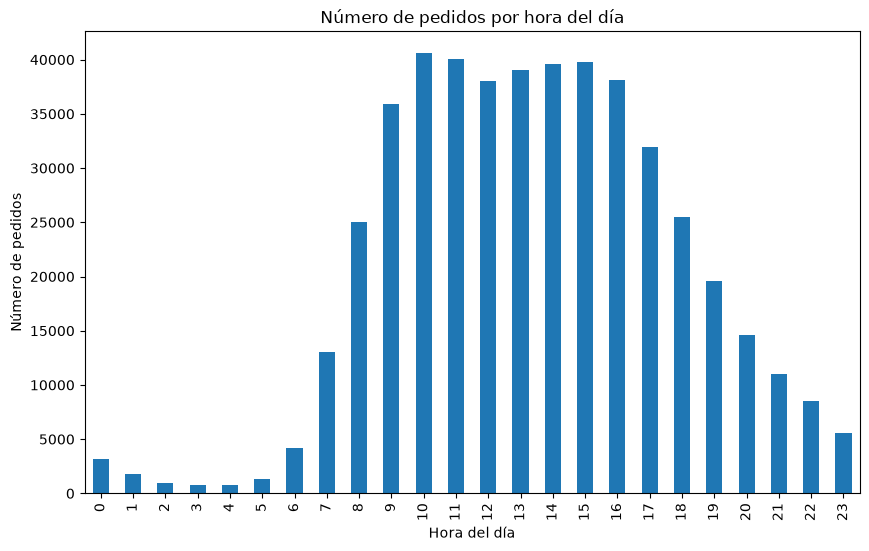

In [102]:
import matplotlib.pyplot as plt

# Cuenta el número de pedidos realizados en cada hora del día
orders_by_hour = (
    orders.groupby('order_hour_of_day')['order_id']
    .count()
)

orders_by_hour.plot(
    kind='bar',
    figsize=(10, 6),
    title='Número de pedidos por hora del día',
    xlabel='Hora del día',
    ylabel='Número de pedidos'
)

plt.show()

Escribe aquí tus conclusiones

La cantidad de pedidos varía considerablemente según la hora del día. La actividad es muy baja durante la madrugada, especialmente entre las 2:00 y las 5:00. A partir de las 6:00, el número de pedidos comienza a aumentar rápidamente y alcanza su punto máximo alrededor de las 10:00, con más de 40,000 pedidos.

El periodo de mayor actividad se encuentra aproximadamente entre las 9:00 y las 16:00. Después de las 16:00, la cantidad de pedidos disminuye gradualmente hasta el final del día. En general, los clientes realizan la mayoría de sus compras durante la mañana y las primeras horas de la tarde.

### [A3] ¿Qué día de la semana compran víveres las personas?

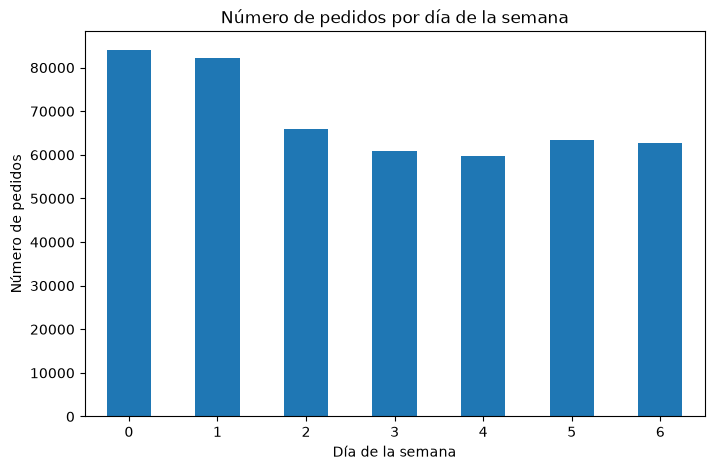

In [103]:
# Cuenta el número de pedidos realizados cada día de la semana
orders_by_day = (
    orders.groupby('order_dow')['order_id']
    .count()
)

orders_by_day.plot(
    kind='bar',
    figsize=(8, 5),
    title='Número de pedidos por día de la semana',
    xlabel='Día de la semana',
    ylabel='Número de pedidos'
)

plt.xticks(rotation=0)
plt.show()

Escribe aquí tus conclusiones

La mayor cantidad de pedidos se realiza los domingos y lunes, con más de 80,000 pedidos en cada día. A partir del martes, el número de pedidos disminuye considerablemente y se mantiene relativamente estable durante el resto de la semana. El jueves presenta la menor cantidad de pedidos, con aproximadamente 60,000. En general, la actividad de compra se concentra principalmente al inicio de la semana.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

Tiempo mínimo de espera: 0 días
Tiempo máximo de espera: 30 días
Tiempo de espera con menos pedidos: 26 días, con 2640 pedidos
Tiempo de espera con más pedidos: 30 días, con 51337 pedidos


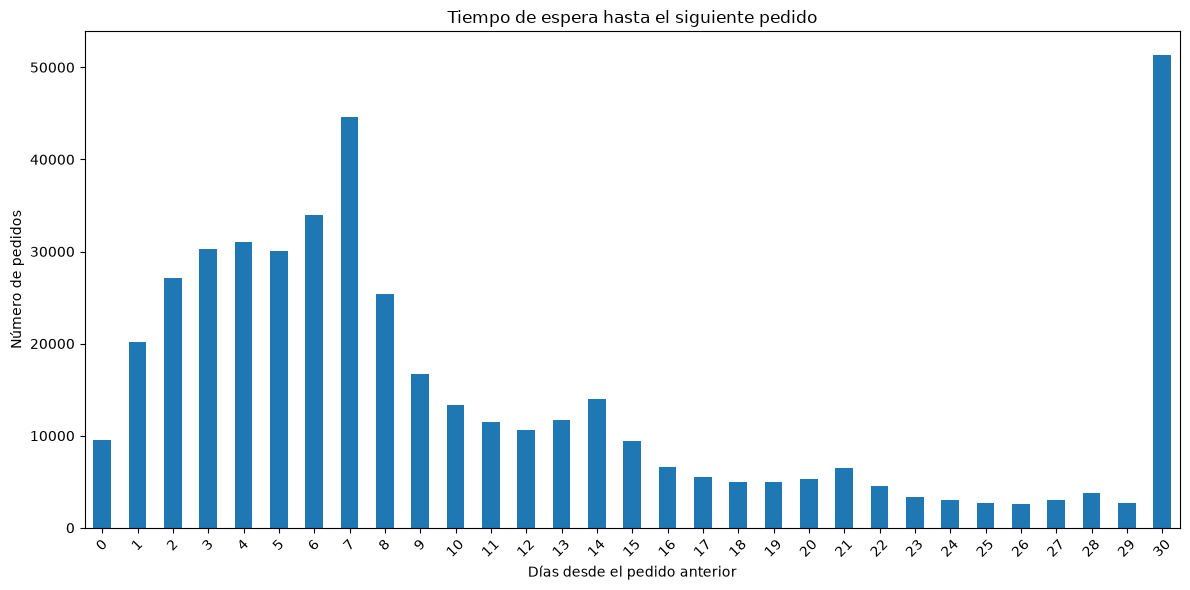

In [104]:
# Cuenta cuántos pedidos corresponden a cada tiempo de espera
orders_by_wait = (
    orders['days_since_prior_order']
    .value_counts()
    .sort_index()
)

# Convierte las etiquetas de días a números enteros
orders_by_wait.index = orders_by_wait.index.astype(int)

# Valores mínimo y máximo de tiempo de espera
minimum_wait = int(orders['days_since_prior_order'].min())
maximum_wait = int(orders['days_since_prior_order'].max())

# Días con la menor y la mayor cantidad de pedidos
day_with_fewest_orders = int(orders_by_wait.idxmin())
day_with_most_orders = int(orders_by_wait.idxmax())

fewest_orders = orders_by_wait.min()
most_orders = orders_by_wait.max()

print('Tiempo mínimo de espera:', minimum_wait, 'días')
print('Tiempo máximo de espera:', maximum_wait, 'días')

print(
    'Tiempo de espera con menos pedidos:',
    day_with_fewest_orders,
    'días, con',
    fewest_orders,
    'pedidos'
)

print(
    'Tiempo de espera con más pedidos:',
    day_with_most_orders,
    'días, con',
    most_orders,
    'pedidos'
)

# Crea el gráfico
orders_by_wait.plot(
    kind='bar',
    figsize=(12, 6),
    title='Tiempo de espera hasta el siguiente pedido',
    xlabel='Días desde el pedido anterior',
    ylabel='Número de pedidos',
    rot=45
)

plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

l tiempo de espera registrado entre pedidos varía entre 0 y 30 días. Un valor de 0 indica que algunos clientes realizaron otro pedido el mismo día. El valor máximo registrado es de 30 días y también es el intervalo más frecuente, con 51,337 pedidos. Si el conjunto de datos limita esta variable a 30, este valor puede representar esperas de 30 días o más.

También se observa una concentración importante en los 7 días, con aproximadamente 44,000 pedidos, lo que sugiere que muchos clientes realizan compras semanalmente. Existen aumentos menores en 14, 21 y 28 días, lo que refuerza la presencia de ciclos de compra semanales. Después de los 7 días, la frecuencia generalmente disminuye conforme aumenta el tiempo de espera.

El intervalo menos frecuente es de 26 días, con 2,640 pedidos.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [105]:
# Selecciona los pedidos realizados los miércoles
wednesday_orders = orders[
    orders['order_dow'] == 3
]

print(wednesday_orders.head())
print('Cantidad de pedidos del miércoles:', len(wednesday_orders))

    order_id  user_id  order_number  order_dow  order_hour_of_day  \
6    2511640   148233            40          3                  8   
16   3109465    55090            19          3                 15   
28    133707   182261             1          3                 10   
30   1890318   193501             3          3                 15   
35    125325   106853             6          3                 19   

    days_since_prior_order  
6                      2.0  
16                     9.0  
28                     NaN  
30                    30.0  
35                    30.0  
Cantidad de pedidos del miércoles: 60897


In [106]:
# Selecciona los pedidos realizados los sábados
saturday_orders = orders[
    orders['order_dow'] == 6
]

print(saturday_orders.head())
print('Cantidad de pedidos del sábado:', len(saturday_orders))

    order_id  user_id  order_number  order_dow  order_hour_of_day  \
0    1515936   183418            11          6                 13   
11    102585   191558            18          6                 16   
14   2843219    74699             4          6                 11   
20     50934   178510             9          6                  9   
26   1844247   122558             4          6                 18   

    days_since_prior_order  
0                     30.0  
11                     8.0  
14                    30.0  
20                     5.0  
26                    30.0  
Cantidad de pedidos del sábado: 62649


In [107]:
# Cuenta los pedidos por hora del miércoles y del sábado
wednesday_by_hour = (
    wednesday_orders['order_hour_of_day']
    .value_counts()
    .sort_index()
)

saturday_by_hour = (
    saturday_orders['order_hour_of_day']
    .value_counts()
    .sort_index()
)

print('Pedidos del miércoles por hora:')
print(wednesday_by_hour)

print('\nPedidos del sábado por hora:')
print(saturday_by_hour)

Pedidos del miércoles por hora:
order_hour_of_day
0      373
1      215
2      106
3      101
4      108
5      170
6      643
7     1732
8     3125
9     4490
10    5026
11    5004
12    4688
13    4674
14    4774
15    5163
16    4976
17    4175
18    3463
19    2652
20    1917
21    1450
22    1154
23     718
Name: count, dtype: int64

Pedidos del sábado por hora:
order_hour_of_day
0      464
1      254
2      177
3      125
4      118
5      161
6      451
7     1619
8     3246
9     4311
10    4919
11    5116
12    5132
13    5323
14    5375
15    5188
16    5029
17    4295
18    3338
19    2610
20    1847
21    1473
22    1185
23     893
Name: count, dtype: int64


                   Miércoles  Sábado
order_hour_of_day                   
0                        373     464
1                        215     254
2                        106     177
3                        101     125
4                        108     118
5                        170     161
6                        643     451
7                       1732    1619
8                       3125    3246
9                       4490    4311
10                      5026    4919
11                      5004    5116
12                      4688    5132
13                      4674    5323
14                      4774    5375
15                      5163    5188
16                      4976    5029
17                      4175    4295
18                      3463    3338
19                      2652    2610
20                      1917    1847
21                      1450    1473
22                      1154    1185
23                       718     893


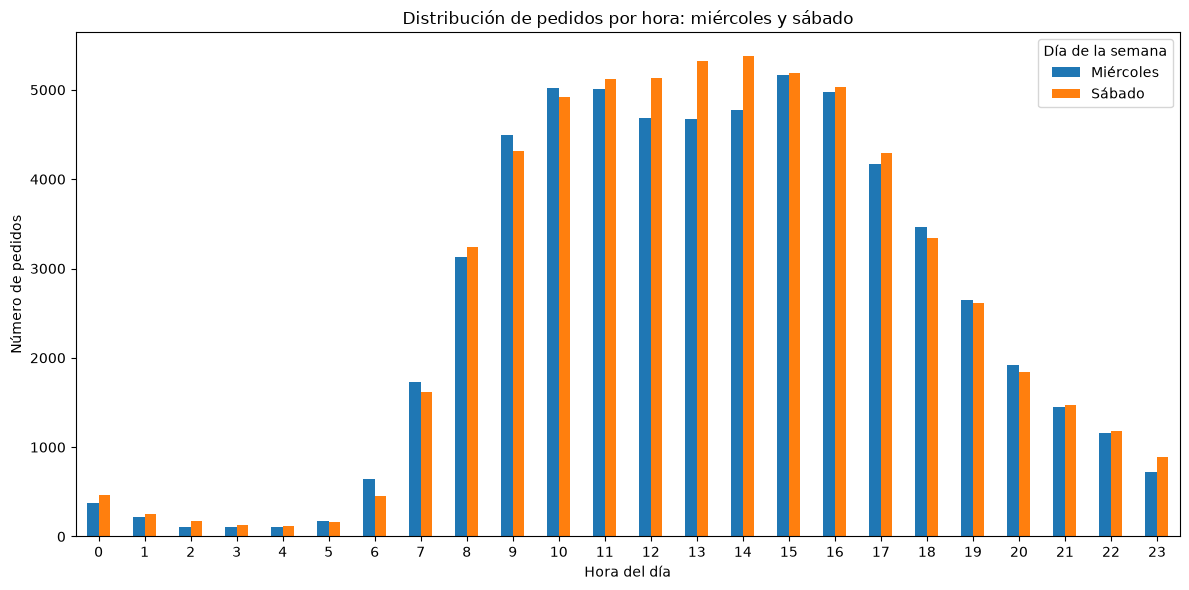

In [108]:
# Une las distribuciones del miércoles y del sábado
orders_by_hour_comparison = pd.concat(
    [wednesday_by_hour, saturday_by_hour],
    axis=1
)

orders_by_hour_comparison.columns = ['Miércoles', 'Sábado']

print(orders_by_hour_comparison)

# Grafica las distribuciones del miércoles y del sábado
orders_by_hour_comparison.plot(
    kind='bar',
    figsize=(12, 6),
    title='Distribución de pedidos por hora: miércoles y sábado',
    xlabel='Hora del día',
    ylabel='Número de pedidos',
    rot=0
)

plt.legend(title='Día de la semana')
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

Las distribuciones del miércoles y del sábado son similares durante la madrugada y la mañana. Sin embargo, alrededor del mediodía aparece una diferencia más marcada: entre las 12:00 y las 14:00, el sábado registra consistentemente más pedidos que el miércoles. La mayor diferencia ocurre a las 13:00, con 5,323 pedidos el sábado frente a 4,674 el miércoles, una diferencia de 649 pedidos.

El miércoles concentra un poco más de actividad durante la mañana, mientras que el sábado presenta un aumento más fuerte entre el mediodía y las primeras horas de la tarde. A las 15:00, las cantidades vuelven a ser casi iguales. En general, el sábado registra ligeramente más pedidos y desplaza su mayor actividad hacia el mediodía.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [109]:
# Cuenta el número de pedidos realizados por cada cliente
orders_per_customer = (
    orders.groupby('user_id')['order_id']
    .count()
)

print(orders_per_customer)
print('Cantidad de clientes:', len(orders_per_customer))
print('Mínimo de pedidos por cliente:', orders_per_customer.min())
print('Máximo de pedidos por cliente:', orders_per_customer.max())

user_id
2         2
4         2
5         1
6         2
7         2
         ..
206203    1
206206    7
206207    5
206208    9
206209    2
Name: order_id, Length: 157437, dtype: int64
Cantidad de clientes: 157437
Mínimo de pedidos por cliente: 1
Máximo de pedidos por cliente: 28


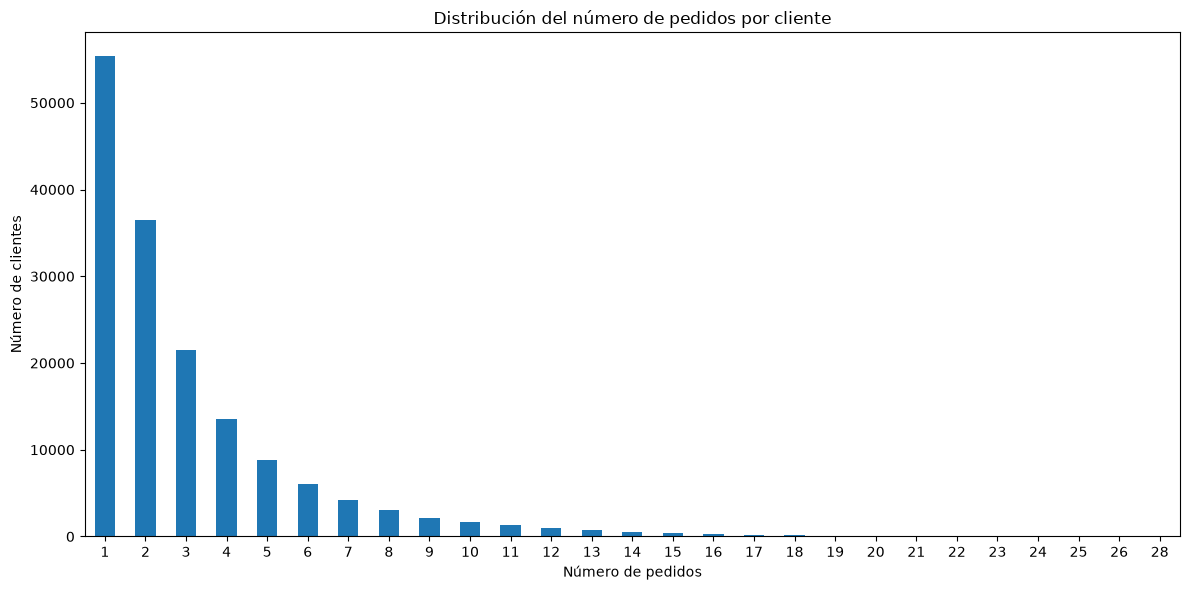

In [110]:
# Calcula la distribución del número de pedidos por cliente
customer_order_distribution = (
    orders_per_customer
    .value_counts()
    .sort_index()
)

# Grafica la distribución del número de pedidos por cliente
customer_order_distribution.plot(
    kind='bar',
    figsize=(12, 6),
    title='Distribución del número de pedidos por cliente',
    xlabel='Número de pedidos',
    ylabel='Número de clientes',
    rot=0
)

plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

La mayoría de los clientes realizó pocos pedidos. La categoría más frecuente es la de un solo pedido, con 55,357 clientes, seguida por dos pedidos, con 36,508 clientes. A medida que aumenta el número de pedidos, la cantidad de clientes disminuye considerablemente. Muy pocos clientes realizaron más de 20 pedidos, y el máximo observado fue de 28 pedidos. Esto muestra una distribución sesgada hacia la derecha, con una alta concentración de clientes en los valores bajos.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [111]:
# Cuenta cuántas veces aparece cada producto y selecciona los 20 más frecuentes
top_20_product_ids = (
    order_products['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)

top_20_product_ids.columns = ['product_id', 'order_count']

print(top_20_product_ids)

    product_id  order_count
0        24852        66050
1        13176        53297
2        21137        37039
3        21903        33971
4        47209        29773
5        47766        24689
6        47626        21495
7        16797        20018
8        26209        19690
9        27845        19600
10       27966        19197
11       22935        15898
12       24964        15292
13       45007        14584
14       39275        13879
15       49683        13675
16       28204        12544
17        5876        12232
18        8277        11993
19       40706        11781


In [112]:
# Agrega el nombre de cada producto
top_20_products = top_20_product_ids.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

# Organiza las columnas
top_20_products = top_20_products[
    ['product_id', 'product_name', 'order_count']
]

print(top_20_products)

    product_id              product_name  order_count
0        24852                    Banana        66050
1        13176    Bag of Organic Bananas        53297
2        21137      Organic Strawberries        37039
3        21903      Organic Baby Spinach        33971
4        47209      Organic Hass Avocado        29773
5        47766           Organic Avocado        24689
6        47626               Large Lemon        21495
7        16797              Strawberries        20018
8        26209                     Limes        19690
9        27845        Organic Whole Milk        19600
10       27966       Organic Raspberries        19197
11       22935      Organic Yellow Onion        15898
12       24964            Organic Garlic        15292
13       45007          Organic Zucchini        14584
14       39275       Organic Blueberries        13879
15       49683            Cucumber Kirby        13675
16       28204        Organic Fuji Apple        12544
17        5876             O

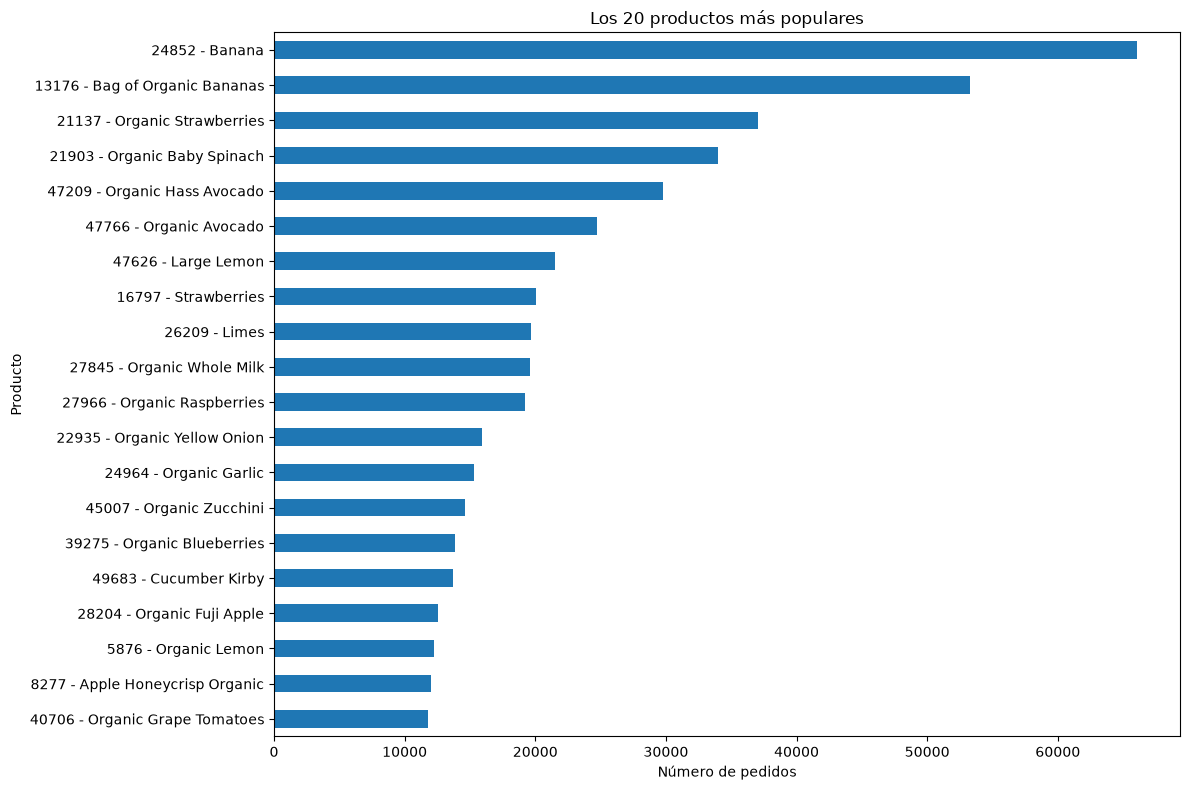

In [113]:
# Crea una etiqueta con el ID y el nombre del producto
top_20_products['product_label'] = (
    top_20_products['product_id'].astype(str)
    + ' - '
    + top_20_products['product_name']
)

# Grafica los 20 productos más populares
top_20_products.plot(
    kind='barh',
    x='product_label',
    y='order_count',
    figsize=(12, 8),
    title='Los 20 productos más populares',
    xlabel='Número de pedidos',
    ylabel='Producto',
    legend=False
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

Los productos más populares son principalmente frutas y verduras. El producto con mayor número de pedidos es Banana (product_id 24852), con 66,050 pedidos, seguido de Bag of Organic Bananas (product_id 13176), con 53,297. En tercer lugar se encuentran las Organic Strawberries, con 37,039 pedidos.

De los 20 productos más populares, 19 corresponden a frutas, verduras o productos frescos, y 15 incluyen la palabra Organic en su nombre. Esto muestra una clara preferencia de los clientes por productos frescos y orgánicos. El único producto fuera de esta categoría es Organic Whole Milk, que ocupa el décimo lugar.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [114]:
# Cuenta el número de productos incluidos en cada pedido
items_per_order = (
    order_products
    .groupby('order_id')['product_id']
    .count()
)

print(items_per_order)
print('Cantidad de pedidos:', len(items_per_order))
print('Mínimo de artículos por pedido:', items_per_order.min())
print('Máximo de artículos por pedido:', items_per_order.max())

order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Name: product_id, Length: 450046, dtype: int64
Cantidad de pedidos: 450046
Mínimo de artículos por pedido: 1
Máximo de artículos por pedido: 127


In [115]:
# Calcula la distribución del número de artículos por pedido
items_per_order_distribution = (
    items_per_order
    .value_counts()
    .sort_index()
)

print(items_per_order_distribution)

product_id
1      21847
2      26292
3      29046
4      31054
5      31923
       ...  
98         1
104        1
108        1
115        1
127        1
Name: count, Length: 90, dtype: int64


Promedio de artículos por pedido: 10.1
Mediana de artículos por pedido: 8.0
Cantidad más frecuente: 5


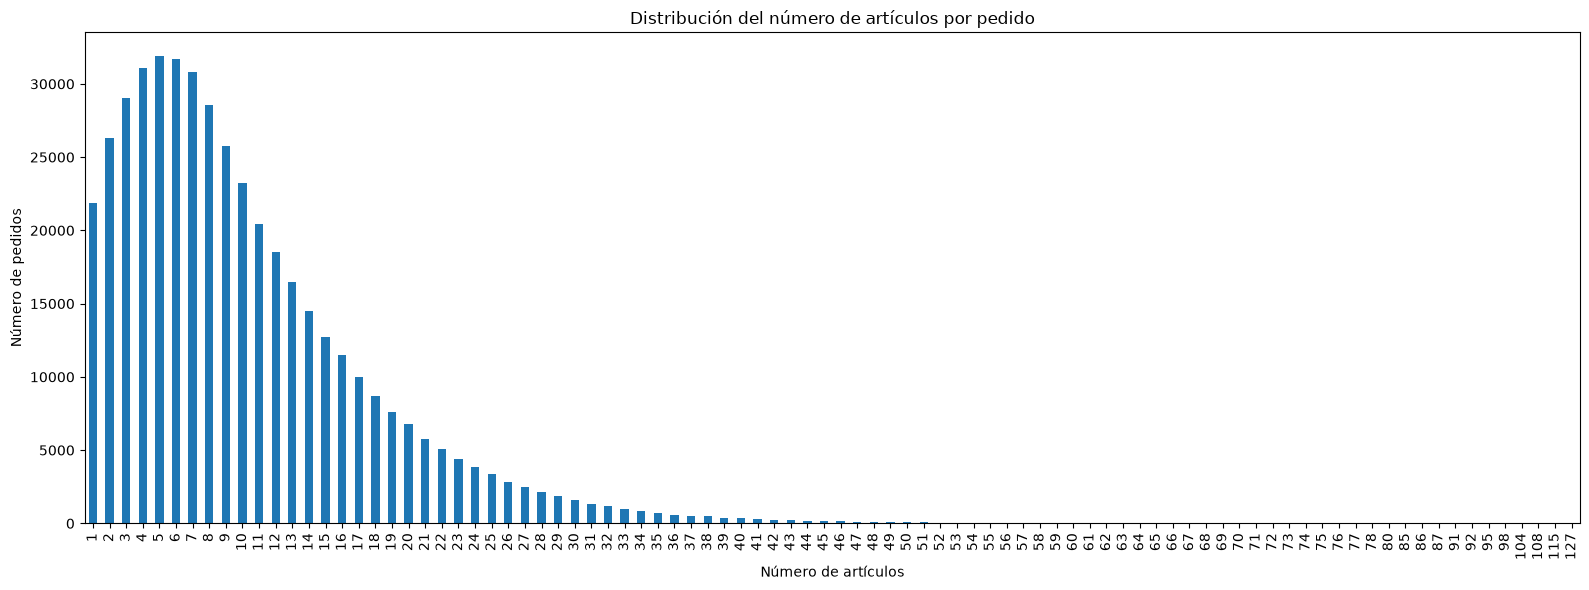

In [116]:
# Calcula medidas representativas del tamaño de los pedidos
print('Promedio de artículos por pedido:', round(items_per_order.mean(), 2))
print('Mediana de artículos por pedido:', items_per_order.median())
print('Cantidad más frecuente:', items_per_order.mode().iloc[0])


# Grafica la distribución
items_per_order_distribution.plot(
    kind='bar',
    figsize=(16, 6),
    title='Distribución del número de artículos por pedido',
    xlabel='Número de artículos',
    ylabel='Número de pedidos',
    rot=90
)

plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

La cantidad de artículos por pedido varía entre 1 y 127. El promedio es de 10.1 artículos, la mediana es de 8 y la cantidad más frecuente es de 5 artículos por pedido.

La distribución está sesgada hacia la derecha: la mayoría de los pedidos contiene pocos productos y la frecuencia disminuye conforme aumenta el número de artículos. La diferencia entre el promedio y la mediana se debe a la presencia de algunos pedidos muy grandes, que elevan el promedio.

En general, un pedido típico contiene entre 5 y 10 artículos, mientras que los pedidos con más de 30 productos son poco frecuentes.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [117]:
# Selecciona únicamente los productos que fueron pedidos nuevamente
reordered_products = order_products[
    order_products['reordered'] == 1
]

print(reordered_products.head())
print('Cantidad de productos reordenados:', len(reordered_products))

   order_id  product_id  add_to_cart_order  reordered
1    567889        1560                  1          1
2   2261212       26683                  1          1
3    491251        8670                 35          1
4   2571142        1940                  5          1
5   2456893       21616                  4          1
Cantidad de productos reordenados: 2683838


In [118]:
# Cuenta cuántas veces se volvió a pedir cada producto
top_20_reordered_ids = (
    reordered_products['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)

top_20_reordered_ids.columns = [
    'product_id',
    'reorder_count'
]

# Ajusta el índice para mostrar posiciones del 1 al 20
top_20_reordered_ids.index = range(
    1,21
)

print(top_20_reordered_ids)

    product_id  reorder_count
1        24852          55763
2        13176          44450
3        21137          28639
4        21903          26233
5        47209          23629
6        47766          18743
7        27845          16251
8        47626          15044
9        27966          14748
10       16797          13945
11       26209          13327
12       22935          11145
13       24964          10411
14       45007          10076
15       49683           9538
16       28204           8989
17        8277           8836
18       39275           8799
19        5876           8412
20       49235           8389


In [119]:
# Agrega el nombre de cada producto reordenado
top_20_reordered_products = top_20_reordered_ids.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

# Organiza las columnas
top_20_reordered_products = top_20_reordered_products[
    ['product_id', 'product_name', 'reorder_count']
]

# Ajusta el índice para mostrar posiciones del 1 al 20
top_20_reordered_products.index = range(
    1,21
)

print(top_20_reordered_products)

    product_id              product_name  reorder_count
1        24852                    Banana          55763
2        13176    Bag of Organic Bananas          44450
3        21137      Organic Strawberries          28639
4        21903      Organic Baby Spinach          26233
5        47209      Organic Hass Avocado          23629
6        47766           Organic Avocado          18743
7        27845        Organic Whole Milk          16251
8        47626               Large Lemon          15044
9        27966       Organic Raspberries          14748
10       16797              Strawberries          13945
11       26209                     Limes          13327
12       22935      Organic Yellow Onion          11145
13       24964            Organic Garlic          10411
14       45007          Organic Zucchini          10076
15       49683            Cucumber Kirby           9538
16       28204        Organic Fuji Apple           8989
17        8277  Apple Honeycrisp Organic        

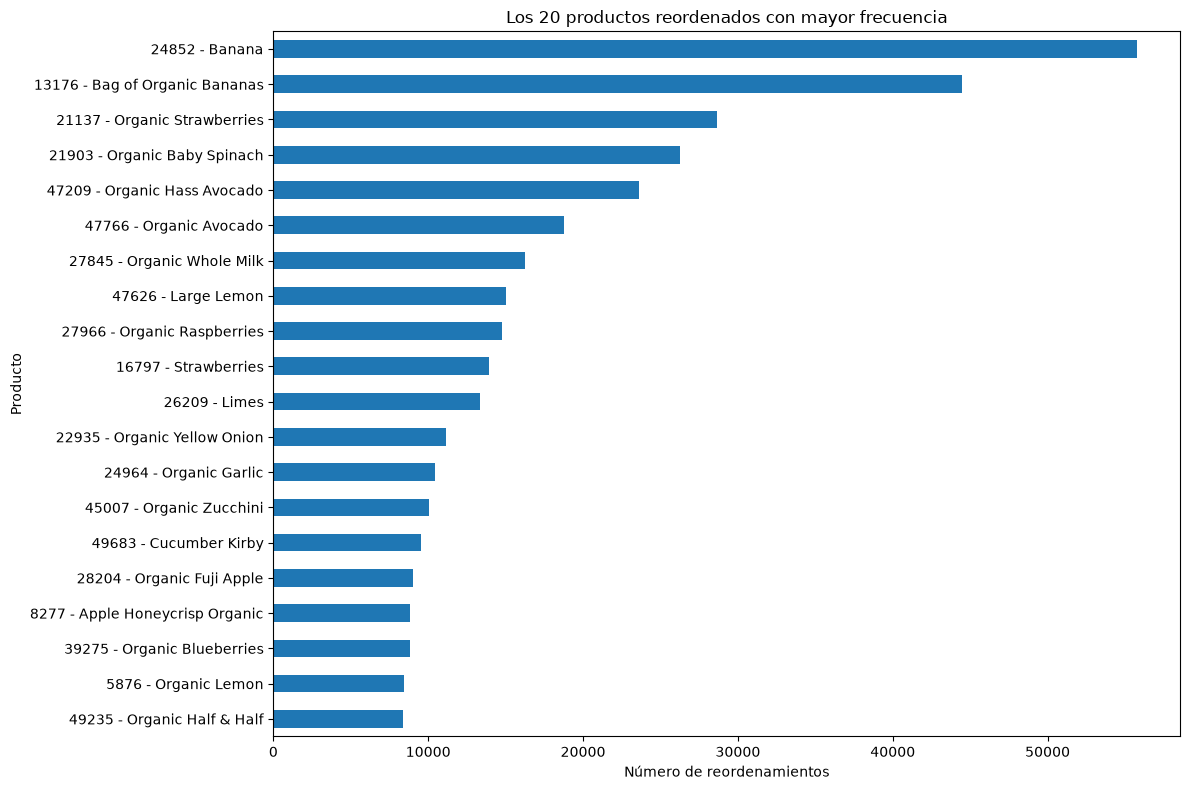

In [120]:
# Crea una etiqueta con el ID y el nombre del producto
top_20_reordered_products['product_label'] = (
    top_20_reordered_products['product_id'].astype(str)
    + ' - '
    + top_20_reordered_products['product_name']
)

# Grafica los 20 productos reordenados con mayor frecuencia
top_20_reordered_products.plot(
    kind='barh',
    x='product_label',
    y='reorder_count',
    figsize=(12, 8),
    title='Los 20 productos reordenados con mayor frecuencia',
    xlabel='Número de reordenamientos',
    ylabel='Producto',
    legend=False
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

Los productos que se vuelven a pedir con mayor frecuencia son principalmente frutas, verduras y otros productos de consumo habitual. Banana (product_id 24852) ocupa el primer lugar, con 55,763 reordenamientos, seguida de Bag of Organic Bananas (product_id 13176), con 44,450, y Organic Strawberries (product_id 21137), con 28,639.

Quince de los veinte productos incluyen la palabra Organic en su nombre. Además, casi todos pertenecen a categorías de productos frescos, como frutas y verduras; las principales excepciones son Organic Whole Milk y Organic Half & Half.

Existe una fuerte coincidencia con la lista de productos más populares obtenida anteriormente. Esto indica que los productos con mayor volumen de pedidos también suelen ser artículos de compra recurrente. Sin embargo, este análisis muestra el número absoluto de reordenamientos, no la proporción de veces que cada producto vuelve a pedirse; esa tasa se calculará por separado en el siguiente ejercicio.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [121]:
# Calcula pedidos totales y reordenados por producto
product_reorder_data = (
    order_products
    .groupby('product_id')['reordered']
    .agg(
        total_orders='count',
        reorder_count='sum'
    )
)

print(product_reorder_data.head())

            total_orders  reorder_count
product_id                             
1                    280            158
2                     11              0
3                     42             31
4                     49             25
7                      2              1


In [122]:
# Calcula la proporción de reordenados por producto
product_reorder_data['reorder_rate'] = (
    product_reorder_data['reorder_count']
    / product_reorder_data['total_orders']
)

print(product_reorder_data.head())

            total_orders  reorder_count  reorder_rate
product_id                                           
1                    280            158      0.564286
2                     11              0      0.000000
3                     42             31      0.738095
4                     49             25      0.510204
7                      2              1      0.500000


In [123]:
# Agrega los nombres de los productos
product_reorder_data = (
    product_reorder_data
    .reset_index()
    .merge(
        products[['product_id', 'product_name']],
        on='product_id',
        how='left'
    )
)

product_reorder_data = product_reorder_data[
    [
        'product_id',
        'product_name',
        'total_orders',
        'reorder_count',
        'reorder_rate'
    ]
]

print(product_reorder_data.head())

   product_id                                       product_name  \
0           1                         Chocolate Sandwich Cookies   
1           2                                   All-Seasons Salt   
2           3               Robust Golden Unsweetened Oolong Tea   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4           7                     Pure Coconut Water With Orange   

   total_orders  reorder_count  reorder_rate  
0           280            158      0.564286  
1            11              0      0.000000  
2            42             31      0.738095  
3            49             25      0.510204  
4             2              1      0.500000  


Escribe aquí tus conclusiones

Se calculó la proporción de reordenamiento de cada producto dividiendo el número de veces que fue reordenado entre el número total de veces que apareció en los pedidos. La tasa toma valores entre 0 y 1: un valor de 0 indica que el producto nunca fue reordenado, mientras que un valor cercano a 1 indica que la mayoría de sus compras fueron repeticiones.

Por ejemplo, Chocolate Sandwich Cookies tiene una tasa aproximada de 0.5643, lo que significa que el 56.43% de sus apariciones fueron reordenamientos. All-Seasons Salt tiene una tasa de 0, mientras que Robust Golden Unsweetened Oolong Tea presenta una tasa aproximada de 73.81%.

Una tasa elevada no implica necesariamente que el producto sea muy popular, ya que algunos productos pueden tener una proporción alta basada en un número reducido de pedidos. Por ello, la tasa debe interpretarse junto con total_orders.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [124]:
# Agrega el identificador del cliente a cada producto pedido
user_order_products = order_products.merge(
    orders[['order_id', 'user_id']],
    on='order_id',
    how='left'
)

print(user_order_products.head())
print('Valores ausentes en user_id:',
      user_order_products['user_id'].isna().sum())

   order_id  product_id  add_to_cart_order  reordered  user_id
0   2141543       11440                 17          0    58454
1    567889        1560                  1          1   129474
2   2261212       26683                  1          1    47476
3    491251        8670                 35          1   134505
4   2571142        1940                  5          1   155995
Valores ausentes en user_id: 0


In [125]:
# Calcula la proporción de productos reordenados por cliente
user_reorder_rate = (
    user_order_products
    .groupby('user_id')['reordered']
    .mean()
)

print(user_reorder_rate)
print('Cantidad de clientes:', len(user_reorder_rate))

user_id
2         0.038462
4         0.000000
5         0.666667
6         0.000000
7         0.928571
            ...   
206203    0.222222
206206    0.714286
206207    0.891304
206208    0.696000
206209    0.320000
Name: reordered, Length: 149626, dtype: float64
Cantidad de clientes: 149626


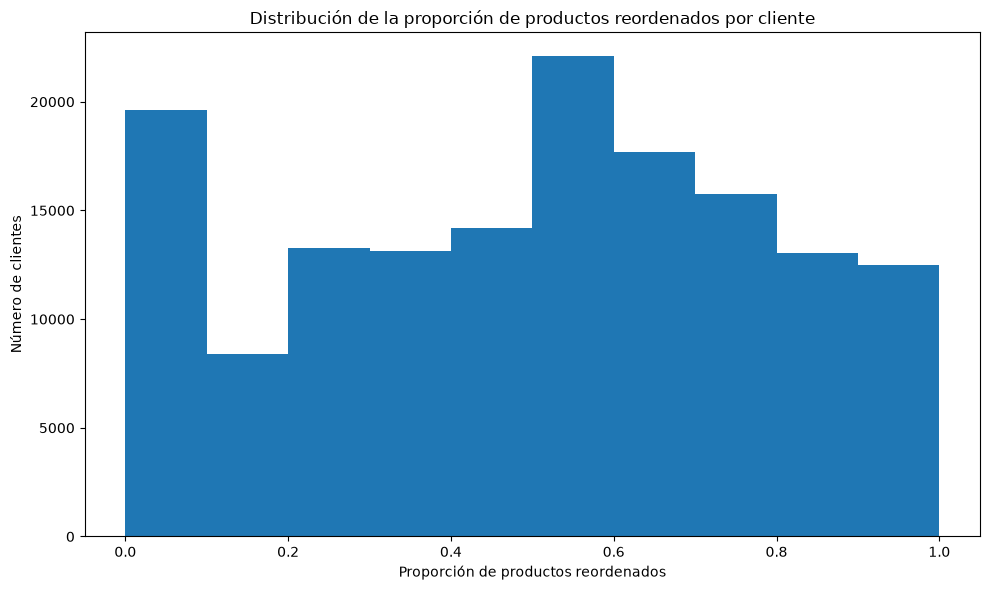

In [126]:
# Grafica la distribución de la proporción de productos reordenados por cliente
user_reorder_rate.plot(
    kind='hist',
    bins=10,
    figsize=(10, 6),
    title='Distribución de la proporción de productos reordenados por cliente'
)

plt.xlabel('Proporción de productos reordenados')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

Se calculó la proporción de productos reordenados para 149,626 clientes. La distribución muestra una amplia variedad de comportamientos, con tasas que van desde 0 hasta 1. Una tasa cercana a 0 indica que casi ninguno de los productos del cliente había sido comprado anteriormente, mientras que una tasa cercana a 1 indica que la mayoría eran productos repetidos.

La mayor concentración de clientes se encuentra aproximadamente entre 0.5 y 0.6, lo que sugiere que muchos combinan productos nuevos con artículos que ya habían comprado. También existe una concentración importante entre 0 y 0.1, correspondiente a clientes con muy pocos reordenamientos.

En general, la distribución no se concentra únicamente en uno de los extremos. Esto indica que los hábitos de compra son variados: algunos clientes prueban principalmente productos nuevos, otros compran mayormente productos habituales y una gran parte mantiene un comportamiento mixto.

Se utilizaron 10 intervalos en el histograma porque permiten observar con claridad el patrón general de la distribución sin resaltar excesivamente pequeñas variaciones producidas por la naturaleza discreta de las proporciones.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [127]:
# Selecciona los productos que fueron añadidos primero al carrito
first_cart_products = order_products[
    order_products['add_to_cart_order'] == 1
]

print(first_cart_products.head())
print(
    'Cantidad de productos añadidos primero:',
    len(first_cart_products)
)

    order_id  product_id  add_to_cart_order  reordered
1     567889        1560                  1          1
2    2261212       26683                  1          1
14   1961225       37553                  1          1
16    639939       10017                  1          1
23    750040        8518                  1          0
Cantidad de productos añadidos primero: 450046


In [128]:
# Cuenta cuántas veces cada producto fue añadido primero al carrito
top_20_first_cart_ids = (
    first_cart_products['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)

top_20_first_cart_ids.columns = [
    'product_id',
    'first_cart_count'
]

# Ajusta el índice para mostrar posiciones del 1 al 20
top_20_first_cart_ids.index = range(
    1,
    len(top_20_first_cart_ids) + 1
)

print(top_20_first_cart_ids)

    product_id  first_cart_count
1        24852             15562
2        13176             11026
3        27845              4363
4        21137              3946
5        47209              3390
6        21903              3336
7        47766              3044
8        19660              2336
9        16797              2308
10       27966              2024
11       44632              1914
12       49235              1797
13       47626              1737
14         196              1733
15       38689              1397
16       26209              1370
17       12341              1340
18        5785              1310
19       27086              1309
20       43352              1246


In [129]:
# Agrega los nombres de los productos
top_20_first_cart_products = top_20_first_cart_ids.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

# Organiza las columnas
top_20_first_cart_products = top_20_first_cart_products[
    ['product_id', 'product_name', 'first_cart_count']
]

# Ajusta nuevamente el índice del 1 al 20
top_20_first_cart_products.index = range(
    1,
    len(top_20_first_cart_products) + 1
)

print(top_20_first_cart_products)

    product_id                 product_name  first_cart_count
1        24852                       Banana             15562
2        13176       Bag of Organic Bananas             11026
3        27845           Organic Whole Milk              4363
4        21137         Organic Strawberries              3946
5        47209         Organic Hass Avocado              3390
6        21903         Organic Baby Spinach              3336
7        47766              Organic Avocado              3044
8        19660                 Spring Water              2336
9        16797                 Strawberries              2308
10       27966          Organic Raspberries              2024
11       44632   Sparkling Water Grapefruit              1914
12       49235          Organic Half & Half              1797
13       47626                  Large Lemon              1737
14         196                         Soda              1733
15       38689     Organic Reduced Fat Milk              1397
16      

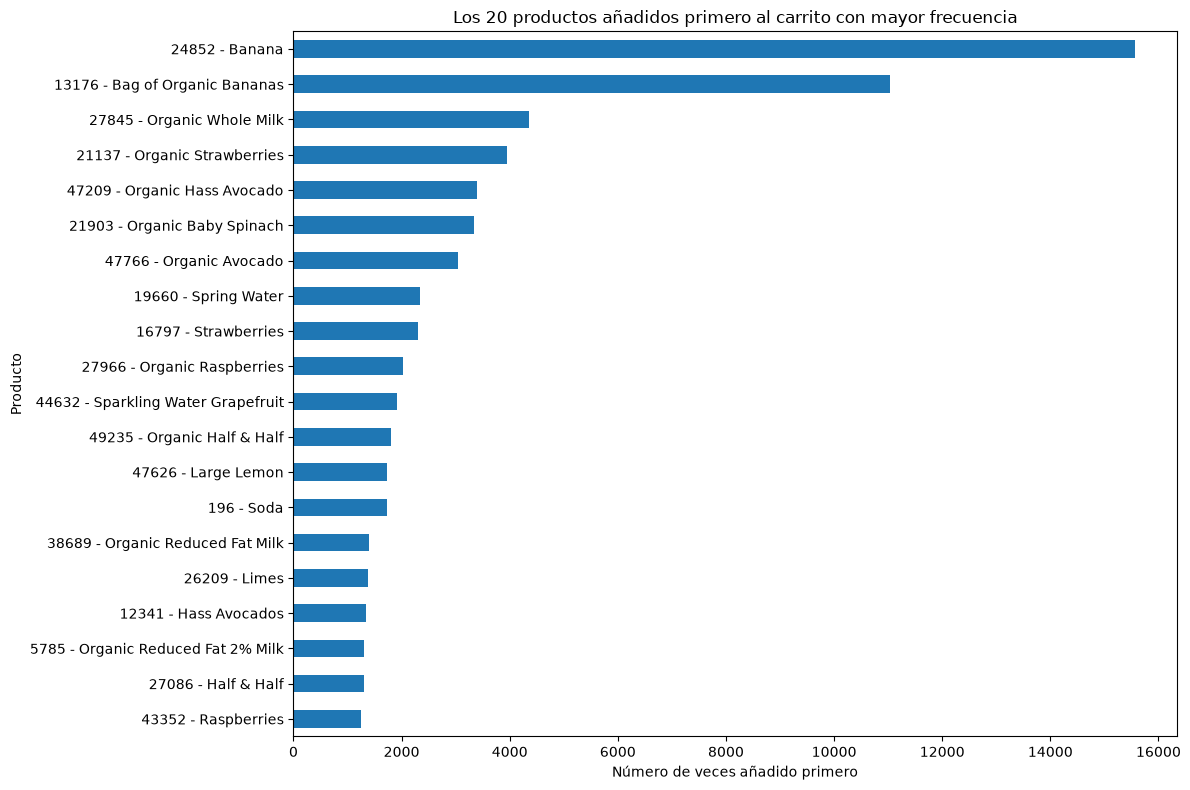

In [130]:
# Crea una etiqueta con el ID y el nombre del producto
top_20_first_cart_products['product_label'] = (
    top_20_first_cart_products['product_id'].astype(str)
    + ' - '
    + top_20_first_cart_products['product_name']
)

# Grafica los 20 productos añadidos primero con mayor frecuencia
top_20_first_cart_products.plot(
    kind='barh',
    x='product_label',
    y='first_cart_count',
    figsize=(12, 8),
    title='Los 20 productos añadidos primero al carrito con mayor frecuencia',
    xlabel='Número de veces añadido primero',
    ylabel='Producto',
    legend=False
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

Los productos que se añaden primero al carrito con mayor frecuencia son principalmente alimentos básicos y de consumo recurrente. Banana (product_id 24852) ocupa claramente el primer lugar, con 15,562 apariciones en primera posición, seguida de Bag of Organic Bananas (product_id 13176), con 11,026. La diferencia entre estos dos productos y el resto es considerable.

Después aparecen productos como leche, fresas, aguacate, espinaca, agua y otros artículos frescos o de consumo habitual. Esto sugiere que muchas personas comienzan sus compras agregando productos que consideran esenciales o que compran regularmente.

Existe una coincidencia importante con los productos más populares y más reordenados identificados anteriormente. Sin embargo, este análisis no mide cuántas veces se compra cada producto en total, sino cuántas veces ocupa específicamente la primera posición del carrito. Por ello, puede interpretarse como una señal de qué productos suelen funcionar como punto de inicio de la compra.

### Conclusion general del proyecto:

Durante el preprocesamiento se identificaron y corrigieron varios problemas de calidad. Se eliminaron 15 filas completamente duplicadas de orders. Los 1,258 nombres de productos ausentes se reemplazaron por Unknown, ya que todos pertenecían al pasillo y departamento identificados como missing. Los 28,817 valores ausentes de days_since_prior_order se conservaron porque corresponden al primer pedido de cada cliente y, por lo tanto, son lógicamente válidos. Además, se encontraron 836 valores ausentes en add_to_cart_order, concentrados en 70 pedidos con más de 64 productos; estos se sustituyeron por 999 como indicador de posición desconocida.

Los pedidos presentan patrones temporales definidos. La actividad es mínima durante la madrugada y aumenta rápidamente a partir de las 6:00. La mayor concentración ocurre entre las 9:00 y las 16:00, con el punto máximo alrededor de las 10:00. Los domingos y lunes registran la mayor cantidad de pedidos, mientras que el jueves presenta la menor. Al comparar miércoles y sábado, ambas distribuciones son similares, aunque el miércoles concentra un poco más de actividad por la mañana y el sábado registra más pedidos alrededor del mediodía, especialmente entre las 12:00 y las 14:00.

El tiempo transcurrido entre pedidos varía entre 0 y 30 días. Se observa una concentración importante en los 7 días y aumentos menores en 14, 21 y 28 días, lo que sugiere la existencia de ciclos de compra semanales. El valor de 30 días es el más frecuente. También existen clientes que realizan un nuevo pedido el mismo día.

La mayoría de los clientes realizó pocos pedidos. De los 157,437 clientes registrados en orders, 55,357 hicieron un solo pedido y 36,508 realizaron dos. La cantidad de clientes disminuye rápidamente conforme aumenta el número de pedidos, y el máximo observado fue de 28 pedidos por cliente. Esto produce una distribución fuertemente sesgada hacia la derecha.

En cuanto al tamaño de los pedidos, se analizaron 450,046 pedidos con productos registrados. Estos contienen entre 1 y 127 artículos. El promedio es de 10.1 productos, la mediana es de 8 y la cantidad más frecuente es de 5. Por lo tanto, un pedido típico contiene aproximadamente entre 5 y 10 artículos, mientras que los pedidos muy grandes son poco comunes.

Los productos más populares son principalmente frutas, verduras y alimentos orgánicos. Banana es el producto más solicitado, con 66,050 apariciones, seguido de Bag of Organic Bananas, con 53,297, y Organic Strawberries, con 37,039. Diecinueve de los veinte productos más populares pertenecen a la categoría de productos frescos, y quince incluyen la palabra Organic.

Los productos con mayor número de reordenamientos coinciden ampliamente con los más populares. Banana también ocupa el primer lugar en compras repetidas, con 55,763 reordenamientos. Esto indica que los productos frescos y de consumo habitual no solo se compran con frecuencia, sino que forman parte recurrente de las compras de los clientes. Sin embargo, la tasa de reordenamiento debe interpretarse junto con el volumen total, ya que un producto con pocas ventas puede presentar una proporción elevada basada en muy pocos registros.

A nivel de cliente, la proporción de productos reordenados muestra comportamientos diversos. La mayor concentración se encuentra aproximadamente entre 0.5 y 0.6, lo que indica que muchos clientes combinan productos nuevos con artículos que ya habían comprado. También existe un grupo importante con tasas cercanas a cero, mientras que otros clientes compran principalmente productos recurrentes.

Finalmente, los productos añadidos primero al carrito también son artículos básicos y de consumo frecuente. Banana fue el primer producto añadido en 15,562 pedidos y Bag of Organic Bananas en 11,026. La coincidencia entre los productos más populares, los más reordenados y los que se agregan primero sugiere que ciertos artículos esenciales funcionan como punto de inicio y eje central de muchas compras.

En conjunto, el análisis muestra una clientela orientada hacia productos frescos y orgánicos, con hábitos de compra recurrentes, ciclos principalmente semanales y pedidos de tamaño moderado. Estos resultados podrían utilizarse para mejorar la planificación de inventarios, destacar productos esenciales, personalizar recomendaciones y programar promociones en los días y horas de mayor actividad. Las conclusiones se limitan a los registros disponibles, y los análisis relacionados con productos corresponden específicamente al subconjunto incluido en order_products.